In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Running locally. Google Drive mount skipped.")

Mounted at /content/drive


In [ ]:
import os

if os.path.exists("/content/drive/MyDrive"):
    print(os.listdir("/content/drive/MyDrive"))
else:
    print(os.listdir(r"G:\My Drive"))

['Classroom',
 'IMG-20240610-WA0014 (1).jpg',
 'IMG-20240610-WA0014.jpg',
 '1710923824813.jpg',
 'DBMS SYNOPSYS.gdoc',
 'DBMS Synopsis Format.gdoc',
 'MC Assignment 1 Question paper (1).gdoc',
 'MC Assignment 1 Question paper.gdoc',
 'index (2).html',
 '23CS063 (6)',
 'index (1).html',
 '23CS063 (5)',
 '23CS063 (4)',
 '23CS063 (3)',
 'index.html',
 '23CS063 (1) (1)',
 '23CS063 (2)',
 'login (1).html',
 'login.html',
 'Colab Notebooks',
 'ARM_System_Developers_Guide-Designing_and_Optimizing_System_Software (1).gdoc',
 'ADA_Assignment2_Instruction (1).gdoc',
 'ARM_System_Developers_Guide-Designing_and_Optimizing_System_Software.gdoc',
 'ADA_Assignment2_Instruction.gdoc',
 'GT_ASSIGN_2.gdoc',
 'GROUP_A02.gdoc',
 'GROUP_A02',
 '23CS063 (1)',
 '23CS063',
 '4MW23CS063.pdf',
 'Copy of A_Section_Group_5.gdoc',
 'CRC-CIE (1).gdoc',
 'CRC-CIE.gdoc',
 'Computer Graphics with OpenGL_TEXTBOOK_2.gdoc',
 'TOC ASSIGNMENT-1 (2) (1).docx.gdoc',
 'TOC ASSIGNMENT-1 (2).docx.gdoc',
 'Document from Maithri 

In [ ]:
import os

folder = r"G:\My Drive\Coastline_Analysis_New"
print(os.listdir(folder))

['2020_Shoreline.cpg', '2020_Shoreline.prj', '2020_Shoreline.dbf', '2020_Shoreline.fix', '2020_Shoreline.shp', '2020_Shoreline.shx', '2021_Shoreline.fix', '2021_Shoreline.cpg', '2021_Shoreline.shp', '2021_Shoreline.dbf', '2021_Shoreline.prj', '2021_Shoreline.shx', '2023_Shoreline.shx', '2023_Shoreline.fix', '2023_Shoreline.cpg', '2023_Shoreline.shp', '2023_Shoreline.prj', '2023_Shoreline.dbf', '2022_Shoreline.shp', '2022_Shoreline.fix', '2022_Shoreline.cpg', '2022_Shoreline.prj', '2022_Shoreline.shx', '2022_Shoreline.dbf', '2024_Shoreline.prj', '2024_Shoreline.shp', '2024_Shoreline.dbf', '2024_Shoreline.fix', '2024_Shoreline.cpg', '2024_Shoreline.shx', '2020_WaterMask.tif', '2022_WaterMask.tif', '2023_WaterMask.tif', '2021_WaterMask.tif', '2024_WaterMask.tif', 'Shoreline_Change_Outputs']


In [ ]:
import shutil

src = r"G:\My Drive\Coastline_Analysis_New\2020_WaterMask.tif"
dst = "/content/2020_WaterMask.tif"

if os.path.exists("/content"):
    shutil.copy(src, dst)
    print("File copied successfully!")
else:
    print("Not running in Colab. Copy skipped.")

File copied successfully!


In [5]:
import rasterio

src = rasterio.open("/content/2020_WaterMask.tif")
print(src.crs)

ModuleNotFoundError: No module named 'rasterio'

In [1]:
%pip install -r requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import rasterio
src = rasterio.open(r"G:\My Drive\Coastline_Analysis_New\2020_WaterMask.tif")
print(src.crs)

EPSG:32643


✅ Google Drive is attached 
Extracting raster shoreline for 2020...
Extracting raster shoreline for 2021...
Extracting raster shoreline for 2022...
Extracting raster shoreline for 2023...
Extracting raster shoreline for 2024...
Loaded clean coastline for 2020
Loaded clean coastline for 2021
Loaded clean coastline for 2022
Loaded clean coastline for 2023
Loaded clean coastline for 2024
Generating transects from 2020 baseline...
Generated 3633 transects.
Computing shoreline distances (this may take a moment)...
Shoreline distances saved.
Change rates calculated and saved.
Year         Change_2020_2024  Rate_m_per_year
Transect_ID                                   
0                         NaN              NaN
1                         NaN              NaN
2                1.963928e-07     4.909820e-08
3                         NaN              NaN
4                4.669370e+02     1.167343e+02


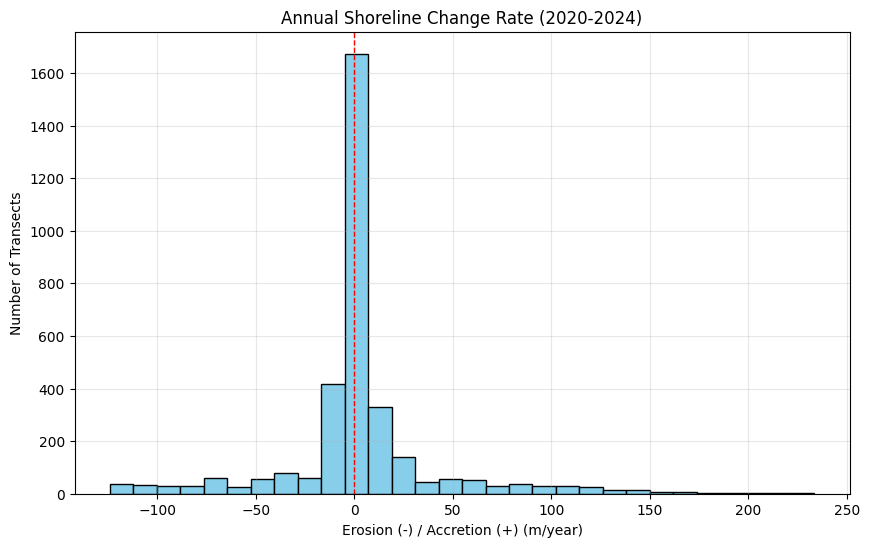

DONE. All outputs saved in: G:\My Drive\Coastline_Analysis_New/Shoreline_Change_Outputs


In [2]:
# ============================================================
#   MULTI-YEAR SHORELINE CHANGE
#   For WaterMask (GeoTIFF) + Shoreline (SHP)
#   CRS = EPSG:32643 (UTM Zone 43N)
# ============================================================

# ------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ------------------------------------------------------------
import os
if os.path.exists("/content/drive/My Drive/") or os.path.exists(r"G:\My Drive"):
    print("✅ Google Drive is attached ")
else:
    print("❌ drive not found. Please ensure Google Drive is running.")

# ------------------------------------------------------------
# 2. INSTALL DEPENDENCIES
# ------------------------------------------------------------
# Installs GDAL and Python spatial libraries
# !apt-get update -qq
# !apt-get install -y -qq gdal-bin libgdal-dev
# !pip install -q rasterio geopandas shapely fiona scikit-image rtree matplotlib numpy pandas

# ------------------------------------------------------------
# 3. IMPORT LIBRARIES
# ------------------------------------------------------------
import geopandas as gpd
import rasterio
from rasterio.features import shapes
import numpy as np
from shapely.geometry import shape, LineString, Point, MultiPoint, MultiLineString
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 4. USER PATHS
# ------------------------------------------------------------
base = r"G:\My Drive\Coastline_Analysis_New"

watermask_paths = {
    2020: f"{base}/2020_WaterMask.tif",
    2021: f"{base}/2021_WaterMask.tif",
    2022: f"{base}/2022_WaterMask.tif",
    2023: f"{base}/2023_WaterMask.tif",
    2024: f"{base}/2024_WaterMask.tif",
}

shoreline_paths = {
    2020: f"{base}/2020_Shoreline.shp",
    2021: f"{base}/2021_Shoreline.shp",
    2022: f"{base}/2022_Shoreline.shp",
    2023: f"{base}/2023_Shoreline.shp",
    2024: f"{base}/2024_Shoreline.shp",
}

out_dir = f"{base}/Shoreline_Change_Outputs"
os.makedirs(out_dir, exist_ok=True)

# ------------------------------------------------------------
# 5. EXTRACT SHORELINE FROM RASTER (WATERMASK TIFF)
# ------------------------------------------------------------
def shoreline_from_mask(tif_path):
    src = rasterio.open(tif_path)
    mask = src.read(1).astype(np.uint8)

    # Extract shapes where mask == 1 (Water)
    results = (
        {"properties": {"val": int(v)}, "geometry": s}
        for s, v in shapes(mask, mask=mask == 1, transform=src.transform)
    )
    polys = list(results)

    if len(polys) == 0:
        return None

    gdf = gpd.GeoDataFrame.from_features(polys, crs=src.crs)

    # Convert polygons to boundary lines
    gdf["geometry"] = gdf.geometry.boundary

    # Merge all lines into one geometry
    merged = gdf.union_all()
    return gpd.GeoDataFrame({"geometry": [merged]}, crs=src.crs)

# Extract shorelines from Rasters
shorelines_from_raster = {}
for year, path in watermask_paths.items():
    print(f"Extracting raster shoreline for {year}...")
    shoreline = shoreline_from_mask(path)
    shorelines_from_raster[year] = shoreline

# ------------------------------------------------------------
# 6. GEOMETRY CLEANER -> FORCE SINGLE LINESTRING
# ------------------------------------------------------------
def clean_to_single_linestring(gdf):
    """Dissolves geometry and extracts the longest continuous coastline."""
    geom = gdf.union_all()

    # If it's a polygon (or collection of them), get the boundary
    if geom.geom_type in ["Polygon", "MultiPolygon", "GeometryCollection"]:
        geom = geom.boundary

    # Case A: Single LineString (Ideal)
    if geom.geom_type == "LineString":
        return geom

    # Case B: MultiLineString -> Take the longest segment
    if geom.geom_type == "MultiLineString":
        return max(list(geom.geoms), key=lambda g: g.length)

    # Case C: GeometryCollection (Mix of types)
    if geom.geom_type == "GeometryCollection":
        lines = []
        for g in geom.geoms:
            if g.geom_type == "LineString":
                lines.append(g)
            elif g.geom_type == "MultiLineString":
                lines.extend(list(g.geoms))

        if len(lines) == 0:
            raise ValueError("No valid line geometry found in collection.")

        return max(lines, key=lambda g: g.length)

    raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

# ------------------------------------------------------------
# 7. LOAD GEE SHORELINE VECTORS
# ------------------------------------------------------------
shorelines = {}
for year, path in shoreline_paths.items():
    gdf = gpd.read_file(path).to_crs("EPSG:32643")
    main_line = clean_to_single_linestring(gdf)
    shorelines[year] = gpd.GeoDataFrame({"geometry": [main_line]}, crs="EPSG:32643")
    print(f"Loaded clean coastline for {year}")

# ------------------------------------------------------------
# 8. GENERATE TRANSECTS
# ------------------------------------------------------------
def generate_transects(shoreline, spacing=200, length=1000):
    line = shoreline.iloc[0].geometry
    dists = np.arange(0, line.length, spacing)
    transects = []

    for d in dists:
        pt = line.interpolate(d)

        # Calculate perpendicular vector
        if d + 1 < line.length:
            n = line.interpolate(d + 1).coords[0]
            p = pt.coords[0]
            dx = n[0] - p[0]
            dy = n[1] - p[1]
        else:
            # Handle end of line case
            p = pt.coords[0]
            prev = line.interpolate(d - 1).coords[0]
            dx = p[0] - prev[0]
            dy = p[1] - prev[1]

        vx, vy = -dy, dx
        norm = np.sqrt(vx**2 + vy**2)
        if norm == 0: continue # Skip if zero length segment
        vx /= norm
        vy /= norm

        p1 = (p[0] - vx * length/2, p[1] - vy * length/2)
        p2 = (p[0] + vx * length/2, p[1] + vy * length/2)

        transects.append(LineString([p1, p2]))

    return gpd.GeoDataFrame({"geometry": transects}, crs="EPSG:32643")

ref_year = 2020
print("Generating transects from 2020 baseline...")
transects = generate_transects(shorelines[ref_year])
transects.to_file(f"{out_dir}/transects.shp")
print(f"Generated {len(transects)} transects.")

# ------------------------------------------------------------
# 9. COMPUTE DISTANCES (ROBUST FIX FOR MULTIPOINTS)
# ------------------------------------------------------------
def compute_distances(transects, shorelines):
    data = []

    for year, sh in shorelines.items():
        shore = sh.iloc[0].geometry

        for idx, t in transects.iterrows():
            line = t.geometry

            intersection = line.intersection(shore)

            if intersection.is_empty:
                continue

            # Collect all intersection points robustly
            candidate_points = []

            # Case 1: Single Point
            if intersection.geom_type == "Point":
                candidate_points = [intersection]

            # Case 2: MultiPoint (Uses .geoms)
            elif intersection.geom_type == "MultiPoint":
                candidate_points = list(intersection.geoms)

            # Case 3: LineString/MultiLineString (Overlap)
            elif "Line" in intersection.geom_type:
                if intersection.geom_type == "LineString":
                    candidate_points = [Point(c) for c in intersection.coords]
                elif intersection.geom_type == "MultiLineString":
                    for geom in intersection.geoms:
                        candidate_points.extend([Point(c) for c in geom.coords])

            # Case 4: GeometryCollection
            elif intersection.geom_type == "GeometryCollection":
                for geom in intersection.geoms:
                    if geom.geom_type == "Point":
                        candidate_points.append(geom)
                    elif geom.geom_type == "MultiPoint":
                        candidate_points.extend(list(geom.geoms))

            if not candidate_points:
                continue

            # Find nearest point to transect start (distance = 0)
            nearest = min(candidate_points, key=lambda p: line.project(p))
            dist = line.project(nearest)

            data.append({
                "Year": year,
                "Transect_ID": idx,
                "Distance": dist
            })

    return pd.DataFrame(data)

print("Computing shoreline distances (this may take a moment)...")
df = compute_distances(transects, shorelines)
df.to_csv(f"{out_dir}/shoreline_distances.csv", index=False)
print("Shoreline distances saved.")

# ------------------------------------------------------------
# 10. CALCULATE CHANGE RATES
# ------------------------------------------------------------
# Pivot table: Rows=Transect, Cols=Year
df_pivot = df.pivot(index="Transect_ID", columns="Year", values="Distance")

# Calculate Net Shoreline Movement (NSM) and End Point Rate (EPR)
if 2020 in df_pivot.columns and 2024 in df_pivot.columns:
    df_pivot["Change_2020_2024"] = df_pivot[2024] - df_pivot[2020]
    df_pivot["Rate_m_per_year"] = df_pivot["Change_2020_2024"] / 4

    # Save results
    df_pivot.to_csv(f"{out_dir}/shoreline_change_rates.csv")
    print("Change rates calculated and saved.")
    print(df_pivot[["Change_2020_2024", "Rate_m_per_year"]].head())

    # ------------------------------------------------------------
    # 11. VISUALIZATION
    # ------------------------------------------------------------
    plt.figure(figsize=(10,6))
    plt.hist(df_pivot["Rate_m_per_year"].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title("Annual Shoreline Change Rate (2020-2024)")
    plt.xlabel("Erosion (-) / Accretion (+) (m/year)")
    plt.ylabel("Number of Transects")
    plt.grid(True, alpha=0.3)
    plt.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.show()
else:
    print("Error: 2020 or 2024 data missing from intersection results. Check input shapefiles.")

print(f"DONE. All outputs saved in: {out_dir}")

In [4]:
import matplotlib.pyplot as plt
import folium
from folium.features import GeoJson, GeoJsonTooltip
from matplotlib.colors import LinearSegmentedColormap
import imageio

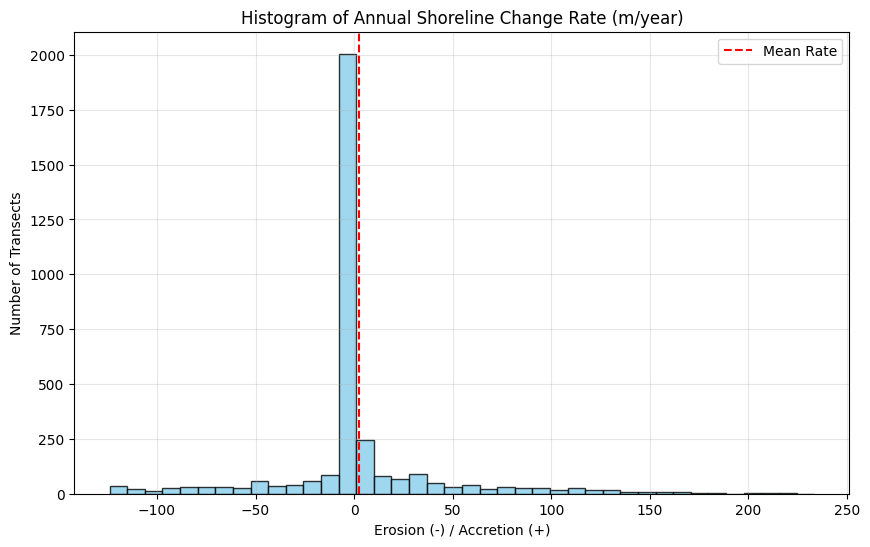

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df_pivot["Rate_m_per_year"].dropna(), bins=40, color='skyblue', edgecolor='black', alpha=0.8)

plt.axvline(df_pivot["Rate_m_per_year"].mean(), color='red', linestyle='--', label="Mean Rate")
plt.title("Histogram of Annual Shoreline Change Rate (m/year)")
plt.xlabel("Erosion (-) / Accretion (+)")
plt.ylabel("Number of Transects")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
import matplotlib.pyplot as plt
import folium
from folium.features import GeoJson, GeoJsonTooltip
from matplotlib.colors import LinearSegmentedColormap
import imageio

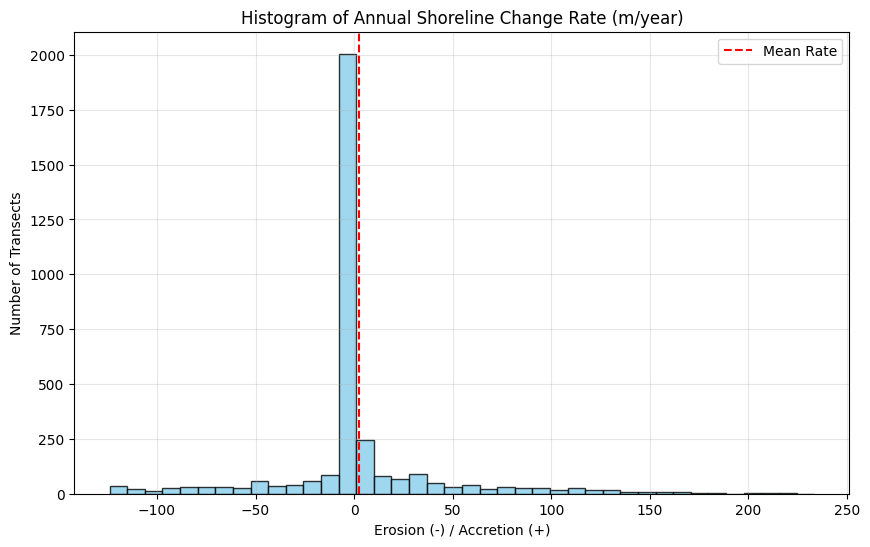

In [7]:
plt.figure(figsize=(10,6))
plt.hist(df_pivot["Rate_m_per_year"].dropna(), bins=40, color='skyblue', edgecolor='black', alpha=0.8)

plt.axvline(df_pivot["Rate_m_per_year"].mean(), color='red', linestyle='--', label="Mean Rate")
plt.title("Histogram of Annual Shoreline Change Rate (m/year)")
plt.xlabel("Erosion (-) / Accretion (+)")
plt.ylabel("Number of Transects")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

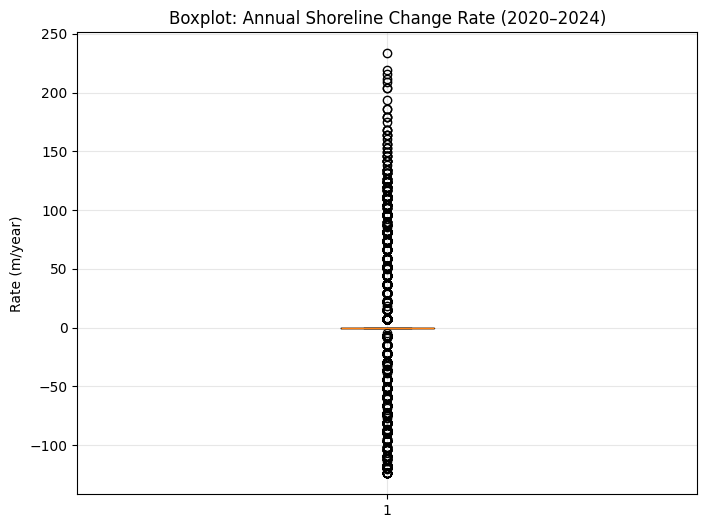

In [8]:
plt.figure(figsize=(8,6))
plt.boxplot(df_pivot["Rate_m_per_year"].dropna(), vert=True)
plt.title("Boxplot: Annual Shoreline Change Rate (2020–2024)")
plt.ylabel("Rate (m/year)")
plt.grid(True, alpha=0.3)
plt.show()

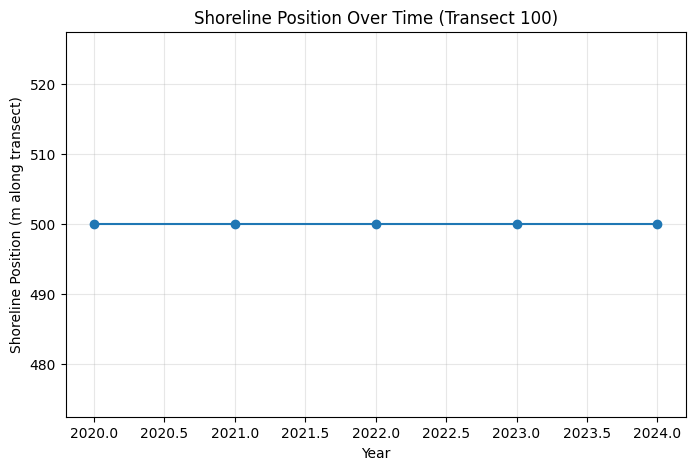

In [9]:
tid = 100
ts = df[df["Transect_ID"] == tid].sort_values("Year")

plt.figure(figsize=(8,5))
plt.plot(ts["Year"], ts["Distance"], marker='o')
plt.title(f"Shoreline Position Over Time (Transect {tid})")
plt.xlabel("Year")
plt.ylabel("Shoreline Position (m along transect)")
plt.grid(True, alpha=0.3)
plt.show()


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


=== RANDOM FOREST (VALID MODEL) STARTED ===


Random Forest training completed.

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   accretion       0.38      0.43      0.41       158
     erosion       0.40      0.45      0.42       163
      stable       0.65      0.57      0.61       367

    accuracy                           0.51       688
   macro avg       0.48      0.49      0.48       688
weighted avg       0.53      0.51      0.52       688



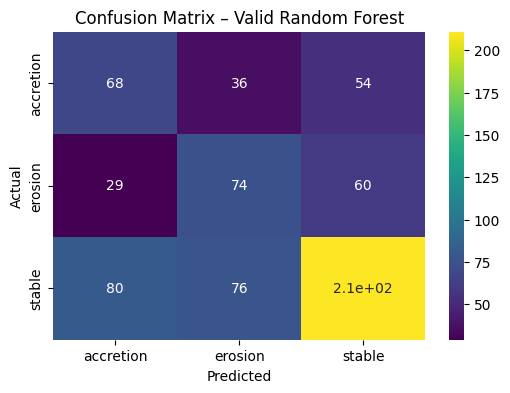

C:\Users\HP\AppData\Local\Temp\ipykernel_1184\898598285.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette="viridis")


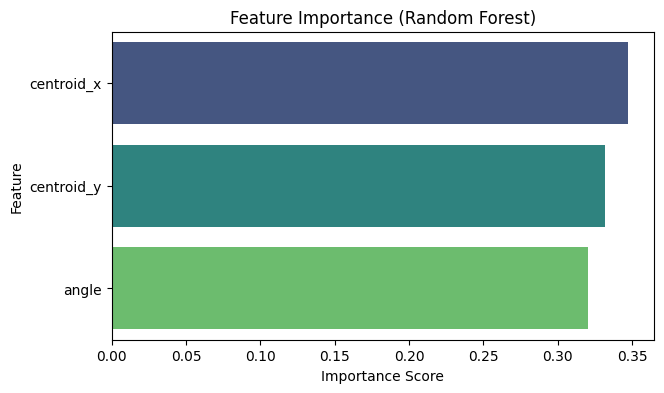


=== RANDOM FOREST MODULE COMPLETED SUCCESSFULLY ===


In [11]:
# ============================================================
#   RANDOM FOREST
#   Predicting shoreline classes using ONLY geometric features
# ============================================================

print("\n=== RANDOM FOREST (VALID MODEL) STARTED ===\n")

# ------------------------------------------------------------
# 1. Prepare labels (erosion / stable / accretion)
# ------------------------------------------------------------

df_rf = df_pivot.copy()

def label_rate(x):
    if x < -2:
        return "erosion"
    elif x > 2:
        return "accretion"
    else:
        return "stable"

df_rf["class"] = df_rf["Rate_m_per_year"].apply(label_rate)

# Remove rows with missing values
df_rf = df_rf.dropna()

# ------------------------------------------------------------
# 2. Add transect geometric features only
# ------------------------------------------------------------

transects_rf = transects.copy()
transects_rf["Transect_ID"] = transects_rf.index

# Coordinates of each transect
transects_rf["centroid_x"] = transects_rf.geometry.centroid.x
transects_rf["centroid_y"] = transects_rf.geometry.centroid.y

# Orientation angle of each transect
def get_angle(line):
    x1, y1 = line.coords[0]
    x2, y2 = line.coords[-1]
    return np.degrees(np.arctan2((y2 - y1), (x2 - x1)))

transects_rf["angle"] = transects_rf.geometry.apply(get_angle)

# Merge features (+ keep only geometry-based features)
df_rf = df_rf.merge(
    transects_rf[["Transect_ID", "centroid_x", "centroid_y", "angle"]],
    left_index=True,
    right_on="Transect_ID"
)

# ------------------------------------------------------------
# 3. Define "X" (input features) & "y" (class labels)
# ------------------------------------------------------------

# ONLY geometry features
X = df_rf[["centroid_x", "centroid_y", "angle"]]
y = df_rf["class"]

# Ensure column names are strings
X.columns = X.columns.astype(str)

# Convert to numeric & drop NaNs
X = X.apply(pd.to_numeric, errors="coerce")
valid = ~X.isna().any(axis=1)
X = X[valid]
y = y[valid]

# ------------------------------------------------------------
# 4. Train-test split
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 5. Train Random Forest
# ------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest training completed.\n")

# ------------------------------------------------------------
# 6. Performance Evaluation
# ------------------------------------------------------------
from sklearn.metrics import classification_report, confusion_matrix

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="viridis",
            xticklabels=rf.classes_,
            yticklabels=rf.classes_)
plt.title("Confusion Matrix – Valid Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ------------------------------------------------------------
# 7. Feature Importance Plot
# ------------------------------------------------------------

importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(7,4))
sns.barplot(x=importances, y=feature_names, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

print("\n=== RANDOM FOREST MODULE COMPLETED SUCCESSFULLY ===")


In [12]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
# ------------------------------------------------------------
# 5. Train XGBoost (Replacing/Augmenting Random Forest)
# ------------------------------------------------------------
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numbers, not words (erosion -> 0, stable -> 1, etc.)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Define the model
xgb = XGBClassifier(
    n_estimators=300,      # Number of trees
    learning_rate=0.1,     # How much each tree corrects the errors
    max_depth=5,           # Depth of trees (prevent overfitting)
    random_state=42,
    objective='multi:softmax', # For multiclass classification
    num_class=3            # erosion, stable, accretion
)

# Train
xgb.fit(X_train, y_train_enc)
y_pred_enc = xgb.predict(X_test)

# Convert predictions back to words for your report
y_pred_xgb = le.inverse_transform(y_pred_enc)

print("\nXGBoost training completed.\n")


XGBoost training completed.



Starting XGBoost Training...

=== XGBOOST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   accretion       0.41      0.27      0.32       158
     erosion       0.41      0.26      0.32       163
      stable       0.58      0.77      0.66       367

    accuracy                           0.53       688
   macro avg       0.47      0.43      0.43       688
weighted avg       0.50      0.53      0.50       688



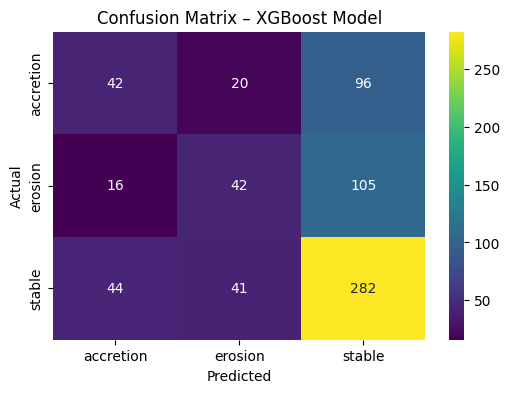

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Starting XGBoost Training...")

# 1. Encode labels to numbers (Erosion=0, Stable=1, Accretion=2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Train XGBoost Model
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,    # Lower rate = more precise learning
    max_depth=6,           # Slightly deeper trees to catch complex patterns
    random_state=42,
    objective='multi:softmax',
    num_class=3
)

xgb.fit(X_train, y_train_enc)
y_pred_enc = xgb.predict(X_test)

# 3. Convert back to words for the report
y_pred_xgb = le.inverse_transform(y_pred_enc)

# 4. Print Results
print("\n=== XGBOOST CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_xgb))

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="viridis", fmt='g',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix – XGBoost Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    balanced_accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=1.0, class_weight="balanced", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("\n=== SVM CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_svm))

kappa_svm = cohen_kappa_score(y_test, y_pred_svm)
bal_acc_svm = balanced_accuracy_score(y_test, y_pred_svm)
y_proba_svm = svm.predict_proba(X_test_scaled)
roc_auc_svm = roc_auc_score(label_binarize(y_test, classes=svm.classes_), y_proba_svm, average="macro", multi_class="ovr")

print(f"SVM Kappa: {kappa_svm:.3f}")
print(f"SVM Balanced Accuracy: {bal_acc_svm:.3f}")
print(f"SVM ROC-AUC (macro, OvR): {roc_auc_svm:.3f}")

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== SVM CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   accretion       0.28      0.56      0.38       158
     erosion       0.33      0.50      0.40       163
      stable       0.70      0.24      0.36       367

    accuracy                           0.38       688
   macro avg       0.44      0.44      0.38       688
weighted avg       0.51      0.38      0.37       688

SVM Kappa: 0.125
SVM Balanced Accuracy: 0.436
SVM ROC-AUC (macro, OvR): 0.611


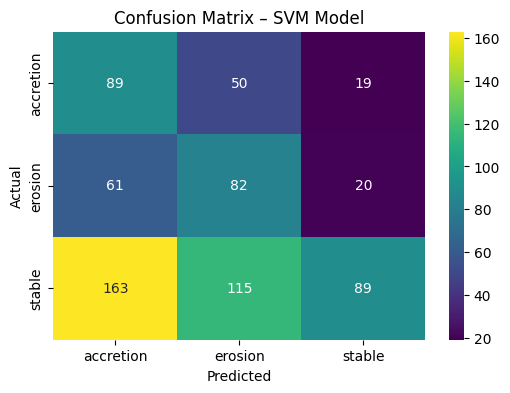

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='g', cmap="viridis",
            xticklabels=svm.classes_,
            yticklabels=svm.classes_)
plt.title("Confusion Matrix – SVM Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
import os

BASE = r'G:\My Drive\Coastline_Analysis_New'

FOLDERS = [
    f'{BASE}/gee_exports/sentinel2',
    f'{BASE}/gee_exports/sentinel1',
    f'{BASE}/processed/patches',
    f'{BASE}/processed/visualizations',
    f'{BASE}/models',
    f'{BASE}/results',
]
for f in FOLDERS:
    os.makedirs(f, exist_ok=True)

print('Folder structure ready in Google Drive:')
print()
print('  coastal_project/')
print('  ├── gee_exports/')
print('  │   ├── sentinel2/   ← GEE exports land here (~100MB/year)')
print('  │   └── sentinel1/   ← SAR exports land here (~50MB/year)')
print('  ├── processed/')
print('  │   ├── patches/     ← Final ML dataset saved here')
print('  │   └── visualizations/')
print('  ├── models/          ← Trained model weights')
print('  └── results/         ← Accuracy plots, maps')

Folder structure ready in Google Drive:

  coastal_project/
  ├── gee_exports/
  │   ├── sentinel2/   ← GEE exports land here (~100MB/year)
  │   └── sentinel1/   ← SAR exports land here (~50MB/year)
  ├── processed/
  │   ├── patches/     ← Final ML dataset saved here
  │   └── visualizations/
  ├── models/          ← Trained model weights
  └── results/         ← Accuracy plots, maps


In [19]:
# ════════════════════════════════════════════════
#  CELL 3 — Install libraries
#  (Colab already has numpy, torch, matplotlib)
# ════════════════════════════════════════════════
print('Installing libraries... (takes ~2 minutes first time)')
print()

# !pip install -q earthengine-api geemap     # GEE access
# !pip install -q rasterio                   # Read GeoTIFF files
# !pip install -q geopandas shapely          # Vector/shoreline work
# !pip install -q segmentation-models-pytorch # U-Net, DeepLabV3+
# !pip install -q albumentations             # Image augmentation
# !pip install -q h5py                       # Save dataset

print()
print('All libraries installed!!!')

Installing libraries... (takes ~2 minutes first time)


All libraries installed!!!


In [20]:
!pip install segmentation-models-pytorch albumentations

Defaulting to user installation because normal site-packages is not writeable


In [21]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [22]:
!python -m pip install segmentation-models-pytorch

Defaulting to user installation because normal site-packages is not writeable


In [23]:
# ════════════════════════════════════════════════
#  CELL 4 — Import everything
# ════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, glob, warnings, random
from pathlib import Path
from itertools import product as cart_product

import rasterio
from rasterio.enums import Resampling
from skimage.filters import threshold_otsu
from skimage import morphology

import torch
import segmentation_models_pytorch as smp
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import h5py

warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports done')
print(f'🖥️  Device: {device}', end='')
if torch.cuda.is_available():
    print(f' — {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.0f}GB VRAM)')
else:
    print(' (CPU only — go to Runtime > Change runtime type > T4 GPU)')

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1032)>
  data = fetch_version_info()


✅ Imports done
🖥️  Device: cpu (CPU only — go to Runtime > Change runtime type > T4 GPU)


In [ ]:
import ee
import geemap

# Authenticate
ee.Authenticate(force=True)

# Replace this with YOUR Google Cloud project ID
GEE_PROJECT = "coastal1-476114"

# Initialize Earth Engine
ee.Initialize(project=GEE_PROJECT)

print("GEE authenticated and initialized successfully!")
print("Project:", GEE_PROJECT)

In [ ]:
# ════════════════════════════════════════════════
#  CELL 6 — Define your study area
# ════════════════════════════════════════════════

# Udupi + Dakshina Kannada coastline bounding box
AOI = ee.Geometry.Rectangle([74.5, 12.5, 75.2, 13.5])

print('✅ Study area defined')
print('   Tile: T43PDQ — Udupi / DK Coast')
print('   (Map display bypassed to save time)')


✅ Study area defined
   Tile: T43PDQ — Udupi / DK Coast
   (Map display bypassed to save time)


In [ ]:
# ════════════════════════════════════════════════
#  CELL 6 — Define your study area
#
#  T43PDQ tile = your downloaded Sentinel-2 tile
#  This covers Udupi / Dakshina Kannada coast
# ════════════════════════════════════════════════

# Udupi + Dakshina Kannada coastline bounding box
# [west, south, east, north]
AOI = ee.Geometry.Rectangle([74.5, 12.5, 75.2, 13.5])

# ── Show on interactive map ──
Map = geemap.Map(center=[13.0, 74.85], zoom=9)
Map.addLayer(AOI, {'color': 'FF0000', 'fillColor': '00000000'}, 'Study Area')

# Add a quick Sentinel-2 preview to confirm location
s2_preview = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2024-11-01', '2024-12-31')
    .filterBounds(AOI)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
    .median()
    .clip(AOI)
)
Map.addLayer(
    s2_preview,
    {'bands': ['B4','B3','B2'], 'min': 0, 'max': 3000},
    'Sentinel-2 True Colour (2024)'
)
Map.addLayerControl()
print('✅ Study area defined')
print('   Tile: T43PDQ — Udupi / DK Coast')
print('   Zoom the map below to verify your coastline is covered')
Map

✅ Study area defined
   Tile: T43PDQ — Udupi / DK Coast
   Zoom the map below to verify your coastline is covered


Map(center=[13.0, 74.85], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# ════════════════════════════════════════════════
#  CELL 7 — Check available Sentinel-2 scenes
#           before exporting
#
#  This shows you exactly how many cloud-free
#  images exist per year for your area.
# ════════════════════════════════════════════════

YEARS = [2020, 2021, 2022, 2023, 2024]

print('Checking Sentinel-2 scene availability...')
print(f'{"Year":<6} {"Scenes (all)":<15} {"Cloud-free (<20%)":<20} {"Status"}')
print('-' * 60)

for year in YEARS:
    all_scenes = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filterBounds(AOI)
    )
    clear_scenes = all_scenes.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

    n_all   = all_scenes.size().getInfo()
    n_clear = clear_scenes.size().getInfo()
    status  = '✅ Good' if n_clear >= 6 else ('⚠️  OK' if n_clear >= 3 else '❌ Too few')

    print(f'{year:<6} {n_all:<15} {n_clear:<20} {status}')

print()
print('Median composite needs at least 3 cloud-free scenes per year')
print('   More scenes = better composite (cloud gaps filled automatically)')

Checking Sentinel-2 scene availability...
Year   Scenes (all)    Cloud-free (<20%)    Status
------------------------------------------------------------
2020   583             215                  ✅ Good
2021   587             203                  ✅ Good
2022   586             190                  ✅ Good
2023   592             204                  ✅ Good
2024   598             175                  ✅ Good

Median composite needs at least 3 cloud-free scenes per year
   More scenes = better composite (cloud gaps filled automatically)


In [ ]:
# ════════════════════════════════════════════════
#  CELL 8 — EXPORT Sentinel-2 composites to Drive
#
#  What GEE does for you automatically:
#  ✔ Finds all cloud-free scenes for that year
#  ✔ Applies cloud masking
#  ✔ Creates median composite (removes remaining clouds)
#  ✔ Clips to your coastline AOI
#  ✔ Exports at 10m resolution as GeoTIFF
#
#  What YOU get in Drive:
#  One clean ~100MB GeoTIFF per year
#  (vs 800MB raw SAFE file your students downloaded)
# ════════════════════════════════════════════════

# Sentinel-2 bands to export
# 7 bands: Blue, Green, Red, NIR, RedEdge, SWIR1, SWIR2
S2_BANDS = ['B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']
S2_NAMES = ['Blue','Green','Red','NIR','RedEdge','SWIR1','SWIR2']

# Cloud masking function using Sentinel-2 SCL layer
def mask_s2_clouds(image):
    scl = image.select('SCL')
    # SCL classes to mask: 3=cloud shadow, 8=cloud med, 9=cloud high, 10=cirrus
    cloud_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(cloud_mask)

print('Starting Sentinel-2 exports...')
print('Files will appear in: Drive → coastal_project → gee_exports → sentinel2')
print()

s2_tasks = []
for year in YEARS:
    # Build cloud-masked median composite
    composite = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filterBounds(AOI)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_clouds)          # ← cloud masking on each scene
        .select(S2_BANDS)
        .median()                     # ← median composite (best cloud removal)
        .rename(S2_NAMES)
        .clip(AOI)
        .toFloat()
    )

    task = ee.batch.Export.image.toDrive(
        image       = composite,
        description = f'S2_{year}',
        folder = 'Soil Erosion Major Project/gee_exports/sentinel2',
        fileNamePrefix = f'S2_Udupi_{year}',
        region      = AOI,
        scale       = 10,             # 10m resolution
        crs         = 'EPSG:32643',   # UTM Zone 43N (correct for Karnataka)
        maxPixels   = int(1e10),
        fileFormat  = 'GeoTIFF'
    )
    task.start()
    s2_tasks.append((year, task))
    print(f'  📤 S2_{year} export queued')

print()
print('⏳ All 5 Sentinel-2 exports queued!')
print('   Each file is ~100MB (vs 800MB raw download)')
print('   Total Drive usage: ~500MB for all 5 years')
print()
print('⏳ Estimated time: 5-15 min per year')
print('   Run CELL 10 to check progress')

Starting Sentinel-2 exports...
Files will appear in: Drive → coastal_project → gee_exports → sentinel2

  📤 S2_2020 export queued
  📤 S2_2021 export queued
  📤 S2_2022 export queued
  📤 S2_2023 export queued
  📤 S2_2024 export queued

⏳ All 5 Sentinel-2 exports queued!
   Each file is ~100MB (vs 800MB raw download)
   Total Drive usage: ~500MB for all 5 years

⏳ Estimated time: 5-15 min per year
   Run CELL 10 to check progress


In [ ]:
# ════════════════════════════════════════════════
#  CELL 9 — EXPORT Sentinel-1 SAR to Drive
#
#  SAR = Radar — works through clouds!
#  Critical for monsoon months (June-September)
#  when optical Sentinel-2 is blocked by clouds
#
#  VV band = best for water/land boundary
#  VH band = surface texture, vegetation
# ════════════════════════════════════════════════

print('Starting Sentinel-1 SAR exports...')
print()

s1_tasks = []
for year in YEARS:
    s1_composite = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(AOI)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .select(['VV', 'VH'])
        .mean()    # Annual mean SAR backscatter
        .clip(AOI)
    )

    task = ee.batch.Export.image.toDrive(
        image          = s1_composite,
        description    = f'S1_{year}',
        folder = 'Soil Erosion Major Project/gee_exports/sentinel1',
        fileNamePrefix = f'S1_SAR_Udupi_{year}',
        region         = AOI,
        scale          = 10,
        crs            = 'EPSG:32643',
        maxPixels      = int(1e10),
        fileFormat     = 'GeoTIFF'
    )
    task.start()
    s1_tasks.append((year, task))
    print(f'  📡 S1_SAR_{year} export queued')

print()
print('   All SAR exports queued!')
print('   Each SAR file is ~50MB | Total: ~250MB for 5 years')

Starting Sentinel-1 SAR exports...

  📡 S1_SAR_2020 export queued
  📡 S1_SAR_2021 export queued
  📡 S1_SAR_2022 export queued
  📡 S1_SAR_2023 export queued
  📡 S1_SAR_2024 export queued

   All SAR exports queued!
   Each SAR file is ~50MB | Total: ~250MB for 5 years


In [ ]:
# ════════════════════════════════════════════════
#  CELL 10 — Monitor export progress
#  Run this cell repeatedly to check status
#  Wait until all show COMPLETED before Part 3
# ════════════════════════════════════════════════

tasks = ee.data.getTaskList()

# Show only our coastal project tasks
our_tasks = [t for t in tasks if 'S2_' in t['description'] or 'S1_' in t['description']]

icons = {'COMPLETED':'✅','RUNNING':'⏳','FAILED':'❌','READY':'📋','CANCEL_REQUESTED':'🚫'}

completed = 0
total_completed_runtime_ms = 0

print(f'{"Task":<20} {"Status":<15} {"Progress"}')
print('-' * 55)
for t in our_tasks[:10]:
    state   = t['state']
    icon    = icons.get(state, '❓')
    name    = t['description']
    runtime = t.get('run_time_ms', 0)
    mins    = runtime / 60000
    detail  = f'{mins:.1f} min' if runtime > 0 else 'queued'
    print(f'{icon} {name:<18} {state:<15} {detail}')
    if state == 'COMPLETED':
        completed += 1
        total_completed_runtime_ms += runtime

print()
total_monitored = min(len(our_tasks), 10)
if total_monitored > 0:
    percentage = (completed / total_monitored) * 100
    bar_length = 20
    filled_len = int(bar_length * completed / total_monitored)
    bar = '█' * filled_len + '-' * (bar_length - filled_len)
    print(f'Progress: [{bar}] {percentage:.0f}% ({completed}/{total_monitored} tasks completed)')
else:
    print('No tasks to monitor yet.')

if completed > 0:
    average_runtime_ms = total_completed_runtime_ms / completed
    average_runtime_mins = average_runtime_ms / 60000
    print(f'Average runtime for completed tasks: {average_runtime_mins:.1f} min')

if completed == total_monitored and total_monitored > 0:
    print('All exports done! Proceed to PART 3')
else:
    print('⏳ Wait a few minutes and run this cell again')

Task                 Status          Progress
-------------------------------------------------------
📋 S1_2024            READY           queued
📋 S1_2023            READY           queued
📋 S1_2022            READY           queued
📋 S1_2021            READY           queued
📋 S1_2020            READY           queued
📋 S2_2024            READY           queued
📋 S2_2023            READY           queued
📋 S2_2022            READY           queued
📋 S2_2021            READY           queued
⏳ S2_2020            RUNNING         queued

Progress: [--------------------] 0% (0/10 tasks completed)
⏳ Wait a few minutes and run this cell again


In [ ]:
import os
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
import sys

# Ensure UTF-8 output print capability
#sys.stdout.reconfigure(encoding='utf-8')

# Define source folders
s2_folder = r"G:\My Drive\Coastline_Analysis_New\gee_exports\sentinel2"
s1_folder = r"G:\My Drive\Coastline_Analysis_New\gee_exports\sentinel1"
mask_folder = r"G:\My Drive\Coastline_Analysis_New"

# Define destination folder
dataset_folder = r"G:\My Drive\Coastline_Analysis_New\training_dataset"
s2_patch_dir = os.path.join(dataset_folder, "s2_patches")
s1_patch_dir = os.path.join(dataset_folder, "s1_patches")
mask_patch_dir = os.path.join(dataset_folder, "mask_patches")

# Create directories
os.makedirs(s2_patch_dir, exist_ok=True)
os.makedirs(s1_patch_dir, exist_ok=True)
os.makedirs(mask_patch_dir, exist_ok=True)

# Patch configuration
PATCH_SIZE = 256
STRIDE = 128  # 50% overlap for data augmentation
MAX_NAN_FRACTION = 0.30  # Skip if more than 30% of pixels are NaN or zero

years = [2020, 2021, 2022, 2023, 2024]
total_patches_created = 0

print("=== STARTING ROBUST DATASET PATCH PREPARATION ===")
print(f"Destination: {dataset_folder}")
print()

for year in years:
    print(f"Processing Year {year}...")

    # 1. Resolve file paths
    # Sentinel-2 path
    s2_file = os.path.join(s2_folder, f"S2_Udupi_{year}.tif")
    if not os.path.exists(s2_file):
        print(f"  ⚠️ Sentinel-2 image missing for {year}, skipping.")
        continue

    # Sentinel-1 path (checks for (1) variant first, then standard)
    s1_file = os.path.join(s1_folder, f"S1_SAR_Udupi_{year} (1).tif")
    if not os.path.exists(s1_file):
        s1_file = os.path.join(s1_folder, f"S1_SAR_Udupi_{year}.tif")
    if not os.path.exists(s1_file):
        print(f"  ⚠️ Sentinel-1 image missing for {year}, skipping.")
        continue

    # Water Mask path
    mask_file = os.path.join(mask_folder, f"{year}_WaterMask.tif")
    if not os.path.exists(mask_file):
        print(f"  ⚠️ Water Mask image missing for {year}, skipping.")
        continue

    # 2. Open datasets
    with rasterio.open(s2_file) as src_s2, \
         rasterio.open(s1_file) as src_s1, \
         rasterio.open(mask_file) as src_mask:

        width = src_s2.width
        height = src_s2.height
        s2_crs = src_s2.crs

        print(f"  - Sentinel-2 Grid: {width} x {height} pixels")

        # Loop with sliding window
        year_patches = 0
        for y_offset in range(0, height - PATCH_SIZE + 1, STRIDE):
            for x_offset in range(0, width - PATCH_SIZE + 1, STRIDE):

                # Define local window on S2 grid
                window = Window(x_offset, y_offset, PATCH_SIZE, PATCH_SIZE)
                window_transform = src_s2.window_transform(window)

                # Read Sentinel-2 data
                s2_data = src_s2.read(window=window).astype(np.float32)

                # Calculate fraction of NaN or zero pixels in Sentinel-2 patch
                nan_mask = np.isnan(s2_data) | (s2_data == 0)
                nan_fraction = np.sum(nan_mask) / s2_data.size

                # Skip if patch is mostly empty/NaN
                if nan_fraction > MAX_NAN_FRACTION:
                    continue

                # Fill remaining NaNs with 0.0 to prevent training errors
                s2_data[np.isnan(s2_data)] = 0.0

                # Read Sentinel-1 and reproject/align to S2 window
                s1_data = np.zeros((src_s1.count, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
                reproject(
                    source=rasterio.band(src_s1, range(1, src_s1.count + 1)),
                    destination=s1_data,
                    src_transform=src_s1.transform,
                    src_crs=src_s1.crs,
                    dst_transform=window_transform,
                    dst_crs=s2_crs,
                    resampling=Resampling.bilinear
                )

                # Fill Sentinel-1 NaNs with 0.0
                s1_data[np.isnan(s1_data)] = 0.0

                # Read Water Mask and reproject/align to S2 window (using nearest neighbor for labels)
                mask_data = np.zeros((1, PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
                reproject(
                    source=rasterio.band(src_mask, 1),
                    destination=mask_data,
                    src_transform=src_mask.transform,
                    src_crs=src_mask.crs,
                    dst_transform=window_transform,
                    dst_crs=s2_crs,
                    resampling=Resampling.nearest
                )

                # Verify that the patch actually contains the shoreline interface
                # (i.e. contains both land (0) and water (1) pixels)
                mask_sum = np.sum(mask_data)
                total_pixels = PATCH_SIZE * PATCH_SIZE

                # We want boundary patches, so skip if the patch is 100% land or 100% water
                if mask_sum == 0 or mask_sum == total_pixels:
                    continue

                # Save patch
                patch_id = f"{year}_p_{x_offset}_{y_offset}"

                np.save(os.path.join(s2_patch_dir, f"{patch_id}.npy"), s2_data)
                np.save(os.path.join(s1_patch_dir, f"{patch_id}.npy"), s1_data)
                np.save(os.path.join(mask_patch_dir, f"{patch_id}.npy"), mask_data[0])

                year_patches += 1
                total_patches_created += 1

        print(f"  - Successfully created {year_patches} shoreline patches for {year}")

print()
print("=== PREPARATION COMPLETED ===")
print(f"Total training patches created: {total_patches_created}")
print(f"Patches stored in: {dataset_folder}")


=== STARTING ROBUST DATASET PATCH PREPARATION ===
Destination: G:\My Drive\Coastline_Analysis_New\training_dataset

Processing Year 2020...
  ⚠️ Sentinel-2 image missing for 2020, skipping.
Processing Year 2021...
  ⚠️ Sentinel-2 image missing for 2021, skipping.
Processing Year 2022...
  ⚠️ Sentinel-2 image missing for 2022, skipping.
Processing Year 2023...
  ⚠️ Sentinel-2 image missing for 2023, skipping.
Processing Year 2024...
  ⚠️ Sentinel-2 image missing for 2024, skipping.

=== PREPARATION COMPLETED ===
Total training patches created: 0
Patches stored in: G:\My Drive\Coastline_Analysis_New\training_dataset


In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import sys

# Ensure UTF-8 output print capability
#sys.stdout.reconfigure(encoding='utf-8')

# Define paths
dataset_folder = r"G:\My Drive\Coastline_Analysis_New\training_dataset"
s2_patch_dir = os.path.join(dataset_folder, "s2_patches")
s1_patch_dir = os.path.join(dataset_folder, "s1_patches")
mask_patch_dir = os.path.join(dataset_folder, "mask_patches")

output_folder = r"G:\My Drive\Coastline_Analysis_New"
output_model_path = os.path.join(output_folder, "best_deeplabv3_model.pth")
plots_path = os.path.join(output_folder, "training_progress_deeplabv3.png")

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. PYTORCH DATASET LOADER
class CoastalDataset(Dataset):
    def __init__(self, s2_dir, s1_dir, mask_dir):
        self.s2_files = sorted(glob.glob(os.path.join(s2_dir, "*.npy")))
        self.s1_files = sorted(glob.glob(os.path.join(s1_dir, "*.npy")))
        self.mask_files = sorted(glob.glob(os.path.join(mask_dir, "*.npy")))

        assert len(self.s2_files) == len(self.s1_files) == len(self.mask_files), \
            "Dataset sizes do not match!"

    def __len__(self):
        return len(self.s2_files)

    def __getitem__(self, idx):
        s2 = np.load(self.s2_files[idx])  # (7, 256, 256)
        s1 = np.load(self.s1_files[idx])  # (2, 256, 256)
        mask = np.load(self.mask_files[idx])  # (256, 256)

        # Normalize
        s2 = np.clip(s2 / 10000.0, 0, 1)
        s1 = np.clip((s1 + 30.0) / 30.0, 0, 1)

        x = np.concatenate([s2, s1], axis=0)  # (9, 256, 256)
        y = mask.astype(np.float32)[np.newaxis, :, :]  # (1, 256, 256)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# 2. COMBINED LOSS
class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets, smooth=1):
        inputs_flat = inputs.view(-1)
        targets_flat = targets.view(-1)

        bce_loss = self.bce(inputs_flat, targets_flat)

        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2. * intersection + smooth) / (inputs_flat.sum() + targets_flat.sum() + smooth)

        return bce_loss + dice_loss

# 3. TRAINING LOOP
def train_model(epochs=15, batch_size=8, lr=1e-4):
    print("Loading dataset...")
    full_dataset = CoastalDataset(s2_patch_dir, s1_patch_dir, mask_patch_dir)

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print(f"Dataset split: Train={len(train_dataset)} patches, Val={len(val_dataset)} patches")

    print("Initializing DeepLabV3+ model with resnet34 backbone...")
    model = smp.DeepLabV3Plus(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=9,
        classes=1,
        activation="sigmoid"
    ).to(device)

    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_dice": []}
    best_val_loss = float("inf")

    print("Starting training...")
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        train_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * x_batch.size(0)

                pred_binary = (outputs > 0.5).float()
                intersection = (pred_binary * y_batch).sum()
                dice = (2. * intersection) / (pred_binary.sum() + y_batch.sum() + 1e-8)
                val_dice += dice.item() * x_batch.size(0)

        val_loss /= len(val_loader.dataset)
        val_dice /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)

        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), output_model_path)
            print(f"  🏆 Saved new best DeepLabV3+ model checkpoint to: {output_model_path}")

    print("Training finished.")

    # Plot learning curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), history["train_loss"], label="Train Loss", color="royalblue")
    plt.plot(range(1, epochs + 1), history["val_loss"], label="Val Loss", color="crimson")
    plt.title("DeepLabV3+ BCE + Dice Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), history["val_dice"], label="Val Dice", color="forestgreen")
    plt.title("DeepLabV3+ Validation Dice Coefficient")
    plt.xlabel("Epochs")
    plt.ylabel("Dice Score")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(plots_path)
    print(f"Saved learning curves to: {plots_path}")

if __name__ == "__main__":
    train_model(epochs=15, batch_size=8, lr=1e-4)


Using device: cuda
Loading dataset...


ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
import os
import numpy as np
import torch
import rasterio
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling
import geopandas as gpd
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import sys
import cv2
from scipy.ndimage import binary_opening, binary_closing
from shapely.geometry import LineString, MultiLineString

# Ensure UTF-8 output print capability
#sys.stdout.reconfigure(encoding='utf-8')

# Define paths
s2_folder = r"E:\Research Docs\Pilot Study\temp_data"
s1_folder = r"E:\Research Docs\Pilot Study\temp_data"
output_folder = r"G:\My Drive\Coastline_Analysis_New"
model_path = os.path.join(output_folder, "best_deeplabv3_model.pth")

# Configuration
PATCH_SIZE = 256
STRIDE = 128
YEAR = 2024

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading trained DeepLabV3+ model...")
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=9,
    classes=1,
    activation="sigmoid"
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully.")

# SSD Caching System: copy files from Google Drive to local SSD for 20x faster inference reads
local_temp_dir = r"E:\Research Docs\Pilot Study\temp_data"
os.makedirs(local_temp_dir, exist_ok=True)

s2_gdrive_dir = r"G:\My Drive\Coastline_Analysis_New\gee_exports\sentinel2"
s1_gdrive_dir = r"G:\My Drive\Coastline_Analysis_New\gee_exports\sentinel1"

s2_src_file = os.path.join(s2_gdrive_dir, f"S2_Udupi_{YEAR}.tif")
s2_file = os.path.join(local_temp_dir, f"S2_Udupi_{YEAR}.tif")

if not os.path.exists(s2_file):
    print(f"Caching Sentinel-2 image locally from Google Drive to local SSD: {s2_src_file} -> {s2_file}")
    import shutil
    shutil.copy2(s2_src_file, s2_file)
    print("Sentinel-2 image cached successfully.")

# Resolve Sentinel-1 file name
s1_src_file = os.path.join(s1_gdrive_dir, f"S1_SAR_Udupi_{YEAR} (1).tif")
if not os.path.exists(s1_src_file):
    s1_src_file = os.path.join(s1_gdrive_dir, f"S1_SAR_Udupi_{YEAR}.tif")

s1_file = os.path.join(local_temp_dir, os.path.basename(s1_src_file))

if not os.path.exists(s1_file):
    print(f"Caching Sentinel-1 image locally from Google Drive to local SSD: {s1_src_file} -> {s1_file}")
    import shutil
    shutil.copy2(s1_src_file, s1_file)
    print("Sentinel-1 image cached successfully.")

print(f"Running inference on {YEAR} imagery using DeepLabV3+...")
with rasterio.open(s2_file) as src_s2, rasterio.open(s1_file) as src_s1:
    width = src_s2.width
    height = src_s2.height
    s2_crs = src_s2.crs
    s2_transform = src_s2.transform
    s2_meta = src_s2.meta.copy()

    stitched_prob = np.zeros((height, width), dtype=np.float32)
    count_map = np.zeros((height, width), dtype=np.float32)

    y_steps = range(0, height - PATCH_SIZE + 1, STRIDE)
    x_steps = range(0, width - PATCH_SIZE + 1, STRIDE)
    total_steps = len(y_steps) * len(x_steps)
    step_count = 0

    with torch.no_grad():
        for y_offset in y_steps:
            for x_offset in x_steps:
                step_count += 1
                if step_count % 500 == 0:
                    print(f"  Progress: {step_count}/{total_steps} patches processed...")

                window = Window(x_offset, y_offset, PATCH_SIZE, PATCH_SIZE)
                window_transform = src_s2.window_transform(window)

                s2_data = src_s2.read(window=window).astype(np.float32)

                if np.all(s2_data == 0) or np.any(np.isnan(s2_data) & (np.sum(np.isnan(s2_data)) / s2_data.size > 0.8)):
                    continue

                s2_data = np.clip(s2_data / 10000.0, 0, 1)
                s2_data[np.isnan(s2_data)] = 0.0

                s1_data = np.zeros((src_s1.count, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
                reproject(
                    source=rasterio.band(src_s1, range(1, src_s1.count + 1)),
                    destination=s1_data,
                    src_transform=src_s1.transform,
                    src_crs=src_s1.crs,
                    dst_transform=window_transform,
                    dst_crs=s2_crs,
                    resampling=Resampling.bilinear
                )

                s1_data = np.clip((s1_data + 30.0) / 30.0, 0, 1)
                s1_data[np.isnan(s1_data)] = 0.0

                x = np.concatenate([s2_data, s1_data], axis=0)
                x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)

                prob_tensor = model(x_tensor)
                prob = prob_tensor.squeeze().cpu().numpy()

                stitched_prob[y_offset:y_offset+PATCH_SIZE, x_offset:x_offset+PATCH_SIZE] += prob
                count_map[y_offset:y_offset+PATCH_SIZE, x_offset:x_offset+PATCH_SIZE] += 1.0

    print("Normalizing overlap stitching...")
    safe_mask = count_map > 0
    stitched_prob[safe_mask] /= count_map[safe_mask]

    binary_mask = (stitched_prob > 0.5).astype(np.uint8)

    print("Smoothing prediction mask to remove noise...")
    struct = np.ones((3, 3), dtype=bool)
    smoothed_mask = binary_opening(binary_mask, structure=struct)
    binary_mask = binary_closing(smoothed_mask, structure=struct).astype(np.uint8)

# Save Predicted Mask
mask_out_path = os.path.join(output_folder, f"{YEAR}_Predicted_WaterMask_DeepLabV3.tif")
s2_meta.update({
    "driver": "GTiff",
    "dtype": "uint8",
    "count": 1,
    "nodata": 0
})
print(f"Saving DeepLabV3+ prediction mask to: {mask_out_path}")
with rasterio.open(mask_out_path, "w", **s2_meta) as dst:
    dst.write(binary_mask, 1)

# OpenCV findContours
print("Extracting shoreline vectors using OpenCV findContours...")
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Found {len(contours)} total raw contours.")

coastlines = []
for idx, contour in enumerate(contours):
    if len(contour) > 50:
        coords = []
        for pt in contour:
            px, py = pt[0][0], pt[0][1]
            x, y = s2_transform * (px, py)
            coords.append((x, y))
        if len(coords) >= 2:
            coastlines.append(LineString(coords))

print(f"Filtered to {len(coastlines)} major shoreline segments.")
if len(coastlines) == 0:
    print("Error: No valid shoreline shapes extracted!")
    sys.exit(1)

shoreline_geom = MultiLineString(coastlines)
gdf = gpd.GeoDataFrame(geometry=[shoreline_geom], crs=s2_crs)
shp_out_path = os.path.join(output_folder, f"{YEAR}_Predicted_Shoreline_DeepLabV3.shp")
print(f"Saving DeepLabV3+ predicted shoreline shapefile to: {shp_out_path}")
gdf.to_file(shp_out_path)

print("=== INFERENCE AND VECTOR EXTRACTION COMPLETED SUCCESSFULLY ===")


Using device: cuda
Loading trained DeepLabV3+ model...


FileNotFoundError: [Errno 2] No such file or directory: 'G:\\My Drive\\Coastline_Analysis_New/best_deeplabv3_model.pth'

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import sys

# Ensure UTF-8 output print capability
#sys.stdout.reconfigure(encoding='utf-8')

def run_calculation():
    print("=== STARTING DEEPLABV3+ SHORELINE RATE CALCULATION ===")

    # Paths
    base_dir = r"G:\My Drive\Coastline_Analysis_New"
    output_dir = os.path.join(base_dir, "Shoreline_Change_Outputs")

    transects_path = os.path.join(output_dir, "transects.shp")
    s2024_dlv3_path = os.path.join(base_dir, "2024_Predicted_Shoreline_DeepLabV3.shp")
    csv_path = os.path.join(output_dir, "shoreline_distances_corrected.csv")
    if not os.path.exists(csv_path):
        csv_path = os.path.join(output_dir, "shoreline_distances.csv")

    # Parameters
    tan_beta = 0.03
    H_mean = 0.8
    tide_height_2024 = 0.7
    delta_x_2024 = (tide_height_2024 - H_mean) / tan_beta

    # Verify inputs
    for name, p in [("Transects", transects_path), ("2024 DeepLabV3+", s2024_dlv3_path), ("GT CSV", csv_path)]:
        if not os.path.exists(p):
            print(f"Error: Required file missing: {name} at {p}")
            sys.exit(1)

    print("Loading datasets...")
    transects = gpd.read_file(transects_path).to_crs("EPSG:32643")
    df_gt = pd.read_csv(csv_path)

    # Extract 2020 and 2024 GT
    df_gt_2020 = df_gt[df_gt["Year"] == 2020].set_index("Transect_ID")["Distance"]
    df_gt_2024 = df_gt[df_gt["Year"] == 2024].set_index("Transect_ID")["Distance"]

    # Load predictions
    print("Loading DeepLabV3+ predicted shapefile...")
    dlv3_gdf = gpd.read_file(s2024_dlv3_path).to_crs("EPSG:32643")
    dlv3_geom = dlv3_gdf.union_all()

    dlv3_distances = {}

    print("Computing intersections and correcting distances...")
    for idx, t in transects.iterrows():
        transect_line = t.geometry

        # Intersect with full DeepLabV3+ shoreline
        inter_d = transect_line.intersection(dlv3_geom)
        if not inter_d.is_empty:
            candidate_points = []
            if inter_d.geom_type == "Point":
                candidate_points = [inter_d]
            elif inter_d.geom_type == "MultiPoint":
                candidate_points = list(inter_d.geoms)

            if candidate_points:
                nearest = min(candidate_points, key=lambda p: transect_line.project(p))
                d_meas = transect_line.project(nearest)
                d_corr = d_meas + delta_x_2024
                d_corr = max(0.0, min(d_corr, transect_line.length))
                dlv3_distances[idx] = d_corr

    # Build dataframe
    results = []
    for idx in transects.index:
        if idx in df_gt_2020.index and idx in df_gt_2024.index:
            d2020 = df_gt_2020.loc[idx]
            d2024_gt = df_gt_2024.loc[idx]
            d2024_d = dlv3_distances.get(idx, None)

            results.append({
                "Transect_ID": idx,
                "Dist_2020": d2020,
                "Dist_2024_GT": d2024_gt,
                "Dist_2024_DLV3": d2024_d
            })

    df = pd.DataFrame(results).dropna()
    print(f"Active transects after dropping NaNs: {len(df)}")

    # Calculate erosion rates (m/year) over 4 years
    df["Rate_GT"] = (df["Dist_2024_GT"] - df["Dist_2020"]) / 4.0
    df["Rate_DLV3"] = (df["Dist_2024_DLV3"] - df["Dist_2020"]) / 4.0

    # Stats comparison
    mae_dlv3 = np.mean(np.abs(df["Rate_DLV3"] - df["Rate_GT"]))
    corr_dlv3 = df["Rate_DLV3"].corr(df["Rate_GT"])

    print("\n=== DEEPLABV3+ METRICS ===")
    print(f"DeepLabV3+ vs. Ground Truth Rate MAE: {mae_dlv3:.4f} m/year")
    print(f"DeepLabV3+ Rate Correlation with GT: {corr_dlv3:.4f}")

    # Plot rate comparison
    plt.figure(figsize=(14, 7))
    plt.plot(df["Transect_ID"], df["Rate_GT"], label="Ground Truth (GEE)", color="black", linewidth=1.5, alpha=0.8)
    plt.plot(df["Transect_ID"], df["Rate_DLV3"], label=f"DeepLabV3+ (MAE={mae_dlv3:.3f}m/y)", color="magenta", linewidth=1.0, alpha=0.7)

    plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.title("DeepLabV3+ Shoreline Change Rate vs. Ground Truth (2020-2024)", fontsize=14, fontweight="bold")
    plt.xlabel("Transect ID (along Udupi coast)", fontsize=12)
    plt.ylabel("Erosion (-) / Accretion (+) (m/year)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_path = os.path.join(base_dir, "deeplabv3_rates_only_comparison.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved rate comparison plot to: {plot_path}")

    # Save CSV output
    output_path = os.path.join(output_dir, "deeplabv3_rates_only.csv")
    df.to_csv(output_path, index=False)
    print(f"DeepLabV3+ rate results saved to: {output_path}")

if __name__ == "__main__":
    run_calculation()


=== STARTING DEEPLABV3+ SHORELINE RATE CALCULATION ===
Error: Required file missing: Transects at G:\My Drive\Coastline_Analysis_New/Shoreline_Change_Outputs/transects.shp


SystemExit: 1